# Titanic 生还预测

使用 `train.csv` 训练 PyTorch 二分类模型，在 `test.csv` 上预测，并生成 Kaggle 格式的 `submission.csv`。本 notebook 同时绘制训练/验证损失和准确率曲线。

In [1]:
import pandas as pd 

train_data = pd.read_csv('train.csv')
test_data=pd.read_csv('test.csv')

print(train_data.shape)
print(test_data.shape)
train_data.head()
train_data.info()
print('训练集缺失值：')
display(train_data.isnull().sum())

print('测试集缺失值：')
display(test_data.isnull().sum())
features =[
    'Pclass',
    'Sex',
    'Age',
    'SibSp',
    'Parch',
    'Fare',
    'Embarked'
]
train_features = train_data[features].copy()
test_features = test_data[features].copy()
display(train_features.head(10))

# 先来处理Age缺失的问题
# 计算年龄中的中位数
age_median = train_features['Age'].median()
print(age_median)

# 用这个中位数来填充训练集和测试集的缺失值
train_features['Age'] = train_features['Age'].fillna(age_median)
test_features['Age'] =test_features['Age'].fillna(age_median)

# 处理测试集中Fare的缺失值
fare_median=train_features['Fare'].median()
test_features['Fare']=test_features['Fare'].fillna(fare_median)

# 处理Embarked缺失值
# 由于Embarked属于str,不能算中位数，一般取众数来填充
embarked_mode = train_features['Embarked'].mode()[0]
train_features['Embarked']=train_features['Embarked'].fillna(embarked_mode)

# 把sex转化为数字
sex_mapping ={'male':0,'female':1}
train_features['Sex']=train_features['Sex'].map(sex_mapping)
test_features['Sex']=test_features['Sex'].map(sex_mapping)

# 把embarked转化为数字
embarked_mapping = {
    'S':0,
    'C':1,
    'Q':2
}
train_features['Embarked']=train_features['Embarked'].map(embarked_mapping)
test_features['Embarked']=test_features['Embarked'].map(embarked_mapping)
print('训练集缺失值')
display(train_features.isnull().sum())
display(test_features.isnull().sum())
train_features.head()

(891, 12)
(418, 11)
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB
训练集缺失值：


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

测试集缺失值：


PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,22.0,1,0,7.2500,S
1,1,female,38.0,1,0,71.2833,C
2,3,female,26.0,0,0,7.9250,S
3,1,female,35.0,1,0,53.1000,S
4,3,male,35.0,0,0,8.0500,S
5,3,male,NaN,0,0,8.4583,Q
6,1,male,54.0,0,0,51.8625,S
7,3,male,2.0,3,1,21.0750,S
8,3,female,27.0,0,2,11.1333,S
9,2,female,14.0,1,0,30.0708,C


28.0
训练集缺失值


Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,0,22.0,1,0,7.2500,0
1,1,1,38.0,1,0,71.2833,1
2,3,1,26.0,0,0,7.9250,0
3,1,1,35.0,1,0,53.1000,0
4,3,0,35.0,0,0,8.0500,0


In [2]:
import torch

torch.manual_seed(42)
from torch.utils.data import TensorDataset,DataLoader,random_split

# 将train_features先转化为numpy形式再转化为tensor形式
x=torch.tensor(
    train_features.values,
    dtype=torch.float32
)

# 训练集的标签也要转化为tensor形式
y=torch.tensor(
    train_data['Survived'].values,
    dtype=torch.float32
).view(-1,1)

# 测试集转化为tensor
x_test =torch.tensor(
    test_features.values,
    dtype=torch.float32
)
# 开始建立Dataset

# 先来设置随机种子
generator = torch.Generator().manual_seed(42)

dataset= TensorDataset(x,y)

# 开始划分训练集（80%）和验证集（20%）
train_size =int(0.8*len(dataset))
valid_size = len(dataset)-train_size

train_dataset,valid_dataset =random_split(
    dataset,
    [train_size,valid_size],
    generator=generator 
)
    
# 建立DataLoader
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)
# 训练集要打乱，验证集不需要打乱
valid_loader =DataLoader(
    valid_dataset,
    batch_size=32,
    shuffle=False
)


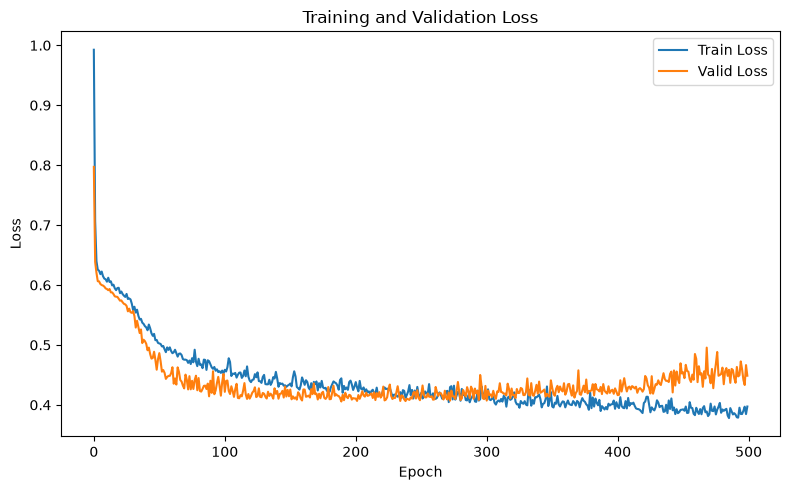

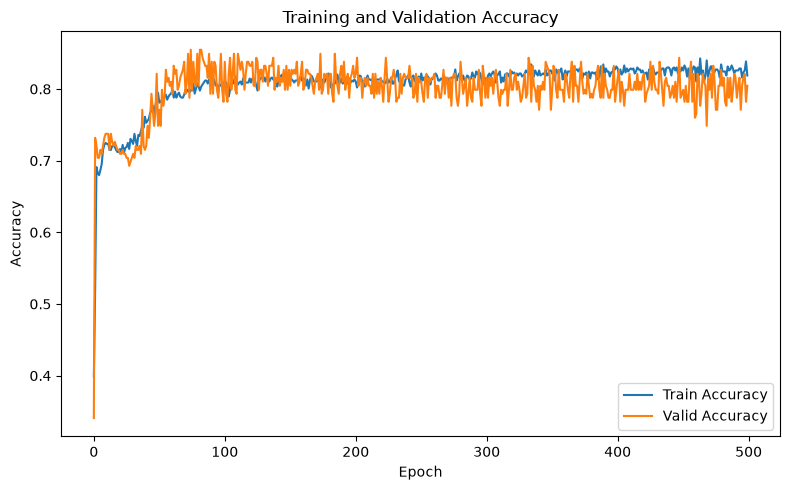

Best validation accuracy: 85.47%


In [3]:
# 开始定义模型，损失函数，优化器，训练模型
class TitanicModel(torch.nn.Module):
    def __init__(self):
        super().__init__()

        self.model = torch.nn.Sequential(
        torch.nn.Linear(7,16),
        torch.nn.ReLU(),

        torch.nn.Linear(16,8),
        torch.nn.ReLU(),

        torch.nn.Linear(8,1)
    )        
    def forward(self,x):
       return self.model(x)

model = TitanicModel()
criterion = torch.nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(model.parameters(),lr=0.001)

# 开始训练

train_losses = []
valid_losses = []

train_accuracies = []
valid_accuracies = []

best_valid_acc = 0

for epoch in range(500):
    # 开始训练
    model.train()

    train_loss=0.0
    train_correct=0.0
    train_total=0.0

    for x_batch,y_batch in train_loader:
        y_pred = model(x_batch)

        loss = criterion(y_pred,y_batch)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        train_loss +=loss.item()

        prob=torch.sigmoid(y_pred)
        pred =(prob >= 0.5).float()

        # 统计正确数量
        train_correct+=(pred == y_batch).sum().item()
        train_total+=y_batch.size(0)
    # 计算平均loss
    avg_train_loss = train_loss / len(train_loader)

    # 计算训练准确率
    train_acc = train_correct / train_total

    # 开始验证
    model.eval()

    valid_loss=0.0
    valid_correct=0.0
    valid_total=0.0

    with torch.no_grad():

        for x_batch,y_batch in valid_loader:

            y_pred = model(x_batch)

            loss = criterion(y_pred,y_batch)

            valid_loss+=loss.item()

            prob = torch.sigmoid(y_pred)
            pred = (prob>=0.5).float()

            valid_correct+=(pred == y_batch).sum().item()
            valid_total+=y_batch.size(0)
            
    # 计算平均loss
    avg_valid_loss = valid_loss / len(valid_loader)
    valid_acc =valid_correct / valid_total

    # 保存数据
    train_losses.append(avg_train_loss)
    valid_losses.append(avg_valid_loss)

    train_accuracies.append(train_acc)
    valid_accuracies.append(valid_acc)

    # 保存最佳模型
    if valid_acc >best_valid_acc:
        best_valid_acc = valid_acc
        torch.save(model.state_dict(),'best_model.pth')
        
import matplotlib.pyplot as plt
from pathlib import Path

results_dir = Path('images')
results_dir.mkdir(exist_ok=True)

plt.figure(figsize=(8, 5))

plt.plot(train_losses, label='Train Loss')
plt.plot(valid_losses, label='Valid Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')

plt.legend()
plt.tight_layout()
plt.savefig(results_dir / 'training_validation_loss.png', dpi=160, bbox_inches='tight')
plt.show()    

plt.figure(figsize=(8, 5))

plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(valid_accuracies, label='Valid Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')

plt.legend()
plt.tight_layout()
plt.savefig(results_dir / 'training_validation_accuracy.png', dpi=160, bbox_inches='tight')
plt.show()
print(f'Best validation accuracy: {best_valid_acc * 100:.2f}%')


In [4]:
model.load_state_dict(torch.load('best_model.pth'))
model.eval()
x_test = torch.tensor(
    test_features.values,
    dtype=torch.float32
)

with torch.no_grad():
    test_logits = model(x_test)
    test_prob = torch.sigmoid(test_logits)
    test_pred = (test_prob >= 0.5).int()
test_pred = test_pred.view(-1).numpy()    
submission = pd.DataFrame({
    'PassengerId': test_data['PassengerId'],
    'Survived': test_pred
})
submission.to_csv('submission.csv', index=False)
print(f'Submission rows: {len(submission)}')

Submission rows: 418
